In [1]:
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) 
sys.path.append(parent_dir)
task_name = 'MemoryCircuits_4s_5r_MAK_REINFORCE_SIL_NLP'
print('Working directory set to:', parent_dir)

Working directory set to: /local0/rossin/git/CRN-GenerativeAI


In [ ]:
# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error_piecewise, dynamic_tracking_error_piecewise_logic
from RL4CRN.rewards.stochastic import dynamic_tracking_error_SSA

from RL4CRN.NLPAgent.Councils.LinearCRNCouncil import LinearCRNCouncil

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/local0/home/rossin/.keys/crn-evolution-be2b980ea837.json"

/local0/rossin/git/CRN-GenerativeAI/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [3]:
# Set the logger to use Comet
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
api_key = "vhIR3uyqsKyU4L7SA8fLCfTSC"
logger = CometLogger(
    api_key=api_key,
    project=task_name,        
    workspace="redsnic", 
    name=f'{task_name}_{timestamp}',
)
logger = logger.experiment

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/redsnic/memorycircuits-4s-5r-mak-reinforce-sil-nlp/1cb9a2f5fea34517af84e4ea56e509ca



In [4]:
# Construct the template CRN
# add dilution and production reactions for all species
productions = []
dilutions = []
n_inputs = 4

# the idea here is to have 3 species: X (input), Set (set/reset), Mem (memory)
# with respective inputs u_X, u_set, u_mem
# in a first time window we register the memory (using Set and Mem) which will determine if the output of our network will be the id(X) or not (NOT(X))

species_labels = ["X", "Set", "Mem", "OUT", "Supp"] 

productions.append(MassAction(reactant_labels=[], product_labels=['X'], input_channels=['u_X'], params=[1.], params_controllability=[True]))
productions.append(MassAction(reactant_labels=[], product_labels=['Set'], input_channels=['u_set'], params=[1.], params_controllability=[True]))
productions.append(MassAction(reactant_labels=[], product_labels=['Mem'], input_channels=['u_mem'], params=[1.], params_controllability=[True]))

# we use no dilution for now

crn_template = IOCRN(productions + dilutions, output_labels=['OUT'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
library = construct_mass_action_library(species_labels=species_labels, order=2)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_X', 'u_mem', 'u_set'] 
Species: ['Mem', 'OUT', 'Set', 'X'] 
Output Species: ['OUT'] 
∅ ----> X;  [MAK(1.0, u_X)]
∅ ----> Set;  [MAK(1.0, u_set)]
∅ ----> Mem;  [MAK(1.0, u_mem)]
Library of possible reactions:
Number of reactions: 421
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X;  [MAK(None)]
R2: ∅ ----> Set;  [MAK(None)]
R3: ∅ ----> Mem;  [MAK(None)]
R4: ∅ ----> OUT;  [MAK(None)]
R5: ∅ ----> Supp;  [MAK(None)]
R6: ∅ ----> X + X;  [MAK(None)]
R7: ∅ ----> Set + X;  [MAK(None)]
R8: ∅ ----> Mem + X;  [MAK(None)]
R9: ∅ ----> OUT + X;  [MAK(None)]
R10: ∅ ----> Supp + X;  [MAK(None)]
R11: ∅ ----> Set + Set;  [MAK(None)]
R12: ∅ ----> Mem + Set;  [MAK(None)]
R13: ∅ ----> OUT + Set;  [MAK(None)]
R14: ∅ ----> Set + Supp;  [MAK(None)]
R15: ∅ ----> Mem + Mem;  [MAK(None)]
R16: ∅ ----> Mem + OUT;  [MAK(None)]
R17: ∅ ----> Mem + Supp;  [MAK(None)]
R18: ∅ ----> OUT + OUT;  [MAK(None)]
R19: ∅ ----> OUT + Supp;  [MAK(None)]
R20: ∅ ----> Supp + Supp;  [MAK(None)]
R21: X ----> ∅;  [M

In [5]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

Using device: cuda
Number of CPUs available: 128


In [6]:
# Flags and filenames
save_flag = True                                                # Save the agent checkpoint
load_flag = False                                               # Load the agent checkpoint 
train_flag = True                                               # Train the agent
save_sheet_flag = True                                          # Save the configuration to an Excel sheet

save_filename = timestamp + '.pth'                              # Filename for saving the agent checkpoint
load_filename = ''                                              # Filename for loading the agent checkpoint
file_name = f"{task_name}.xlsx"             # Filename for saving the Excel sheet

In [ ]:
# Hyperparameters
max_added_reactions = 10                             
N_CPUs = os.cpu_count()                             
N = 10*N_CPUs                                       
width = 1024                                        
depth = 5                                           
deep_layer_size = 1024*10                           
learning_rate = 1e-4                                
hall_of_fame_size = 100                              
entropy_scheduler = {                               
    'entropy_weight': 1e-3, 
    'topk_entropy_weight' : 1.0,
    'remainder_entropy_weight' : 1.0,
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.0
}
entropy_weights_per_head = {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0} 
structure_head_temperature = {"target_entropy_ratio_to_max": np.log(5)/np.log(M), "initial_temperature": 1.0, "rate": 0.0, "current_temperature": 1.0}
risk_scheduler = {                                  
    'risk': 0.9, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 300                                     
render_schedule = 10                                 
render_mode = {                                     
    'style': 'logger', 
    'task': 'transients', 
    'format': 'image',
    'topology': True,
    'bounds': [2.5]
}
ordering_parameters = {
    'enforce_ordering': False,
    'constraint_weight' : float('inf')
}
sil_settings = {
    'sil_loss_weight': 1.0,
    'sil_use_adaptive_baseline': False,
    'sil_baseline_annealing_rate': 0.95
}
render_n_best = 10                                                    
render_disregard_percentage = 0.99                                    
continuous_distribution = {"type": 'lognormal_1D'}

# Time horizon for the simulation (we repeat this twice)
t_f = 500                                           # Final time for the simulation
N_t = 1000                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
# all combination of inputs between 0 and 1 
nums = [0., 1.]

# at t0, S=1 and while Mem and X can be in {0,1}
u_list_t0 = [np.array([u[0], 1, u[1]]) for u in product(*[nums for _ in range(2)])] # list of input combinations, each input is a numpy array of shape (p,)
# at t1, S=0 and while Mem and X can be in {0,1}
u_list_t1 = [np.array([u[0], 0, u[1]]) for u in product(*[nums for _ in range(2)])] # list of input combinations, each input is a numpy array of shape (p,)

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.0 for _ in species_labels]])

# Construct the weights for the performance metric
# w = np.ones(N_t)
# w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
# w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
# w = w[np.newaxis, :]
# No transients
w = np.zeros((1, 2*N_t))
w[:, -1] = 1.0 * N_t

# 1. Zip inputs to create pairs: [[u_t0_c1, u_t1_c1], [u_t0_c2, u_t1_c2], ...]
# u_sequence_list = list(zip(u_list_t0, u_list_t1))
# do the prouct instead to have all combinations
u_sequence_list = []
for u0 in u_list_t0:
    for u1 in u_list_t1:
        u_sequence_list.append([u0, u1])

r_list = []
for u_seq in u_sequence_list:
    # when set=1, output should be X
    if u_seq[0][2] == 1: # identity
        r_list.append(np.array([u_seq[1][0]]))
    else: # NOT
        r_list.append(np.array([1 - u_seq[1][0]]))

print("Number of scenarios:", len(u_sequence_list))
print("Input sequences:", u_sequence_list)
print("Desired outputs:", r_list)


def compute_wobble(trajectory, fraction=0.1):
    """
    Calculates the instability of a trajectory's tail.
    Args:
        trajectory: Numpy array of shape (q, time_steps).
        fraction: The fraction of the end of the trajectory to check (0.1 = last 10%).
    Returns:
        float: Scalar penalty (0.0 = perfectly stable).
    """
    # trajectory shape is (q, time_steps)
    q, n_steps = trajectory.shape
    
    # Determine the slice index for the tail
    cut_off = int(n_steps * (1.0 - fraction))
    
    # Extract the tail (last 10%)
    tail = trajectory[:, cut_off:]
    
    # 1. Calculate Steady State Value (Mean of the tail over time)
    # shape becomes (q, 1) to allow broadcasting
    steady_state_val = np.mean(tail, axis=1, keepdims=True)
    
    # 2. Calculate Deviation of every point in the tail from that steady state
    deviation = np.abs(tail - steady_state_val)
    
    # 3. Return the average deviation (the "thickness" of the line)
    return np.mean(deviation)

def compute_reward(state):
    # 1. Setup Initial Conditions and Horizons
    x0_list = ic.get_ic(state)
    
    # We have two distinct phases (Write, Read), so we pass the horizon twice
    time_horizons_list = [time_horizon, time_horizon] 

    # 2. Run the Simulation & Compute Standard Tracking Error
    # This function populates state.last_task_info['outputs']
    loss, info = dynamic_tracking_error_piecewise_logic(
        state, 
        u_sequence_list,       
        x0_list, 
        time_horizons_list, 
        r_list,                
        w, 
        norm=1, 
        LARGE_NUMBER=1e4
    )
    
    # 3. Retrieve Trajectories for Stability Analysis
    # info['outputs'] is a list of arrays, each with shape (q, total_time_steps)
    y_list = info.get('outputs', [])
    
    # 4. Compute Stability Penalty
    W_STABILITY = 10.0  # High weight: A latch that drifts is useless
    stability_penalty = 0.0
    
    for traj in y_list:
        # The trajectory contains Phase 1 and Phase 2 concatenated.
        # We assume the two phases have equal length (N_t).
        n_total_steps = traj.shape[1]
        midpoint = n_total_steps // 2
        
        # --- Phase 1 Check (Write Memory) ---
        # Did the system settle after writing?
        traj_phase1 = traj[:, :midpoint]
        wobble_1 = compute_wobble(traj_phase1)
        
        # --- Phase 2 Check (Read/Hold Memory) ---
        # Did the system hold the value stable while reading?
        traj_phase2 = traj[:, midpoint:]
        wobble_2 = compute_wobble(traj_phase2)
        
        stability_penalty += (wobble_1 + wobble_2)

    # Average the penalty across all scenarios
    if len(y_list) > 0:
        stability_penalty /= len(y_list)

    # 5. Combine and Return
    # We add the stability penalty to the standard tracking loss
    total_loss = loss + (W_STABILITY * stability_penalty)
    
    # (Optional) Update info for logging if you want to see the breakdown later
    state.last_task_info['tracking_loss'] = loss
    state.last_task_info['stability_penalty'] = stability_penalty
    state.last_task_info['reward'] = total_loss # Update the main reward field
    
    return total_loss, state.last_task_info

Number of scenarios: 16
Input sequences: [[array([0., 1., 0.]), array([0., 0., 0.])], [array([0., 1., 0.]), array([0., 0., 1.])], [array([0., 1., 0.]), array([1., 0., 0.])], [array([0., 1., 0.]), array([1., 0., 1.])], [array([0., 1., 1.]), array([0., 0., 0.])], [array([0., 1., 1.]), array([0., 0., 1.])], [array([0., 1., 1.]), array([1., 0., 0.])], [array([0., 1., 1.]), array([1., 0., 1.])], [array([1., 1., 0.]), array([0., 0., 0.])], [array([1., 1., 0.]), array([0., 0., 1.])], [array([1., 1., 0.]), array([1., 0., 0.])], [array([1., 1., 0.]), array([1., 0., 1.])], [array([1., 1., 1.]), array([0., 0., 0.])], [array([1., 1., 1.]), array([0., 0., 1.])], [array([1., 1., 1.]), array([1., 0., 0.])], [array([1., 1., 1.]), array([1., 0., 1.])]]
Desired outputs: [array([1.]), array([1.]), array([0.]), array([0.]), array([0.]), array([0.]), array([1.]), array([1.]), array([1.]), array([1.]), array([0.]), array([0.]), array([0.]), array([0.]), array([1.]), array([1.])]


In [8]:
if save_sheet_flag:
    sheet_name = "Data"
    headers = [
        "Timestamp", "URL",
        "Epochs Completed", "Successful", "Saved", "Comments",
        "Learning Rate", "Epochs #",
        "(m, n, p, N)",
        "NN Depth", "NN Width", "Deep Layer Size", "CPUs #",
        "Entropy Scheduler",
        "Risk Scheduler",
        "Render Schedule", "HoF Size",
        "Simulation Time", "Time Steps #",
        "Initial Conditions #", "Input Scenarios#",
        "Continuous Distribution", "Entropy Weights per Head",
        "Structure Head Temperature",
        "Ordering Enforced",
        "SIL Settings"
    ]

    data_row = [
        timestamp, logger.url,
        None, None, None, None,
        learning_rate, epoch_num,
        str((max_added_reactions, len(species_labels), p, N)),
        depth, width, deep_layer_size, N_CPUs,
        str(entropy_scheduler),
        str(risk_scheduler),
        render_schedule, hall_of_fame_size,
        t_f, N_t, len(ic.values), len(u_list_t0),
        str(continuous_distribution), str(entropy_weights_per_head),
        str(structure_head_temperature),
        f"Yes: {ordering_parameters['constraint_weight']}" if ordering_parameters['enforce_ordering'] else "No",
        str(sil_settings)
    ]

    if os.path.exists(file_name):
        wb = load_workbook(file_name)
        if sheet_name in wb.sheetnames:
            ws = wb[sheet_name]
        else:
            ws = wb.create_sheet(sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    # Write headers if sheet is empty
    if ws.max_row == 1 and ws.max_column == 1 and ws.cell(row=1, column=1).value is None:
        for col, header in enumerate(headers, start=1):
            ws.cell(row=1, column=col, value=header)

    # Append experiment as next row
    next_row = ws.max_row + 1
    for col, value in enumerate(data_row, start=1):
        ws.cell(row=next_row, column=col, value=value)

    # Freeze header row and add filter
    ws.freeze_panes = "B1" 
    ws.auto_filter.ref = ws.dimensions

    # === Auto-fit column widths (except URL column) ===
    # URL column is column 2 (B), we leave its width unchanged.
    url_col_index = 2

    for col in range(1, ws.max_column + 1):
        if col == url_col_index:
            continue  # keep URL column width as-is

        max_length = 0
        for row in range(1, ws.max_row + 1):
            cell = ws.cell(row=row, column=col)
            value = cell.value
            if value is not None:
                # Convert to string to measure length
                length = len(str(value))
                if length > max_length:
                    max_length = length

        # Some padding so text isn't touching the cell border
        adjusted_width = max_length + 2 if max_length > 0 else 10
        col_letter = get_column_letter(col)
        ws.column_dimensions[col_letter].width = adjusted_width

    wb.save(file_name)
    print(f"New experiment data saved in row {next_row} of '{file_name}'.")

New experiment data saved in row 14 of 'MemoryCircuits_4s_5r_MAK_REINFORCE_SIL_NLP.xlsx'.


In [9]:
# Construct parallel environments
crn_0 = crn_template.clone()
mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
# mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [10]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                    combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])

if ordering_parameters["enforce_ordering"]:
    policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                        combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])
else:
    policy = AddReactionByIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head)

# Construct the agent
agent = REINFORCEAgent(policy, allow_input_influence=False, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, sil_settings=sil_settings, device=device)
if load_flag:
    agent.policy.load_state_dict(torch.load(load_filename+'.pth', map_location=device))

In [11]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library, allow_input_observation=False)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [15]:
import time
# ==========================================
# 0. SETUP & UTILS
# ==========================================
IS_ORDERED_POLICY = "Ordered" in agent.policy.__class__.__name__
print(f"Policy detected: {agent.policy.__class__.__name__}")
print(f"Gemini Injection Mode: {'SORTED (Ordered Trajectory)' if IS_ORDERED_POLICY else 'UNSORTED (Permutation Invariant)'}")

# ==========================================
# 1. LINEAR CRN COUNCIL CONFIGURATION
# ==========================================
PROJECT_ID = "crn-evolution"

gemini_task_desc = (
    f"TASK: Design a 'Latched Programmable Logic Gate' using a Chemical Reaction Network.\n"
    f"The system has 3 inputs: \n"
    f" - u1: Data Signal (Variable)\n"
    f" - u2: Write Enable (Control)\n"
    f" - u3: Configuration Bit (Instruction)\n\n"
    
    f"FUNCTIONAL REQUIREMENTS:\n"
    f"1. LATCHING (Memory): When u2 is High (1.0), the system must memorize the state of u3. "
    f"   When u2 goes Low (0.0), this state must be preserved, regardless of how u3 changes subsequently.\n"
    f"2. PROGRAMMABLE LOGIC: The output species 'r' depends on the Data (u1) and the Latched Memory (M):\n"
    f"   - If Latched M = 1: Output follows u1 (Identity/Buffer behavior).\n"
    f"   - If Latched M = 0: Output inverts u1 (NOT gate behavior: Output = 1 - u1).\n\n"
    
    f"The species you can use are written in this list {species_labels}"
    f"The network will be evaluated in with a simulation covering two intervals, one where set is 1 (the first interval), and another where it is 0 (the second interval)"
    f"Select exactly {max_added_reactions} reactions (exluding the template reactions) from the provided library to achieve this functionality."
    f"IMPORTANT: You need to generate MULPLE CANDIDATE SOLUTIONS that can be evaluated and compared. So select MULTIPLE SETS of {max_added_reactions} reactions.\n"
)

# Instantiate the Council
council_system = LinearCRNCouncil(
    project_id=PROJECT_ID, 
    location="global"
)

# --- DEFINE SPLIT CONTEXTS (The "Board") ---
# 1. Conceptual Library (For reasoning agents: Narrator -> Player)
library_description = (
    f"Mass Action Kinetics (Order 2).\n"
    f"Available Species: {species_labels}\n"
    f"Valid Reaction Types:\n"
    f" - Unimolecular: A -> B (or A -> B + C)\n"
    f" - Bimolecular:  A + B -> C (or A + B -> C + D)\n"
    f" - Synthesis:    0 -> A\n"
    f" - Degradation:  A -> 0\n"
    f"*Do not concern yourself with reaction indices. Focus on topology.*"
)

# 2. Explicit Library (For the Writer ONLY)
library_explicit_str = str(library)

gemini_schedule = 10  

# ==========================================
# 2. TRAINING LOOP
# ==========================================
if train_flag:
    agent.policy.train()
    warm_start_triggered = False
    debate_transcript_file = f"council_transcript_{task_name}_{time.strftime('%Y%m%d_%H%M%S')}.txt"

    for i in tqdm(range(epoch_num, epoch_num*2)):
        
        # --- A. Standard RL Step ---
        mult_env.reset()
        for j in range(max_added_reactions):
            observations = mult_env.observe(observer, tensorizer)
            actions, raw_actions = agent.act(observations, actuator)
            out = mult_env.step(actions, stepper, raw_actions=raw_actions)
        
        rewards = mult_env.get_reward(compute_reward)
        mult_env.hall_of_fame.add_all(mult_env.envs)

        successful_count = sum(1 for env in mult_env.envs if not env.state.last_task_info.get('has_diverged', False))
        if logger:
            logger.log_metric("Successful Environments (%)", successful_count/N, step=i)
        
        # --- B. GEMINI COUNCIL PHASE ---
        should_run_debate = (i > 0 and i % gemini_schedule == 0) or (i == 1 and not warm_start_triggered)

        if should_run_debate:
            if i == 1: warm_start_triggered = True
            
            start_time = time.time()
            print(f"\n[Gemini] Epoch {i}: Convening the Council...")
            
            # 1. Run the Council Session 

            candidates, transcript = council_system.run_debate_session(
                task_desc=gemini_task_desc,
                hof_iter=mult_env.hall_of_fame,
                library_description=library_description,     # <--- Conceptual Context
                library_explicit_str=library_explicit_str,   # <--- Syntax Context (Writer only)
                max_added_reactions=max_added_reactions
            )
            
            # 2. Save Transcript
            with open(debate_transcript_file, "a", encoding="utf-8") as f:
                f.write(f"\n\n=== EPOCH {i} ===\n")
                f.write(transcript)
            print(f"[Gemini] Transcript appended to {debate_transcript_file}.")
            
            # 3. Evaluate, Transplant & Track
            new_gemini_envs = council_system.evaluate_and_transplant(
                candidates=candidates,
                crn_template=crn_template,
                max_added_reactions=max_added_reactions,
                library=library,
                stepper=stepper,
                actuator=actuator,
                compute_reward_func=compute_reward,
                is_ordered_policy=IS_ORDERED_POLICY,
                logger=logger
            )

            # 4. Inject into Hall of Fame
            if new_gemini_envs:
                mult_env.hall_of_fame.add_all(new_gemini_envs)

            elapsed_time = time.time() - start_time
            print(f"[Gemini] Council Adjourned in {elapsed_time:.2f}s. {len(new_gemini_envs)} candidates ratified.")
            
            if logger:
                logger.log_metric("Gemini Candidates", len(new_gemini_envs), step=i)
                logger.log_metric("Gemini Duration (s)", elapsed_time, step=i)
                if len(mult_env.hall_of_fame) > 0:
                    best_env = mult_env.hall_of_fame[0] 
                    logger.log_metric("HoF Best Loss", best_env.state.last_task_info.get('reward'), step=i)

        # --- C. Agent Update ---
        agent.update(
            rewards, 
            step_iteration=i, 
            hof=mult_env.hall_of_fame, 
            observer=observer, 
            tensorizer=tensorizer, 
            stepper=stepper, 
            use_sil=True, 
            sil_weighting_scheme='uniform', 
            sil_batch_size=None
        )

        if i % render_schedule == 0:
            mult_env.render(rewards, n_best=render_n_best, disregarded_percentage=render_disregard_percentage, mode=render_mode)

/local0/rossin/git/CRN-GenerativeAI/.venv/lib/python3.10/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Policy detected: AddReactionByIndex
Gemini Injection Mode: UNSORTED (Permutation Invariant)


  0%|          | 0/300 [00:00<?, ?it/s]


[cvHandleFailure, Error: -15] At t = 3.5843873067379, unable to satisfy inequality constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvHandleFailure, Error: -15] At t = 10.7646897052055, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.315128670202612, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 212.355886344756, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -3] At t = 319.789883060415 and h = 0.000880324855090458, the error test failed repeatedly or with |h| = hmin.


[cvHandleFailure, Error: -15] At t = 75.1458167712597, unable to satisfy inequality constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvHandleFailure, Error: -15] At t = 118.74050

  0%|          | 1/300 [10:22<51:39:54, 622.05s/it]

...

 99%|█████████▉| 298/300 [13:03:33<04:02, 121.47s/it]


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvHandleFailure, Error: -15] At t = 1.54633927249813, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 250.301121134202, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 182.981790215955, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 100.554447360202, unable to satisfy inequality constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvHandleFailure, Error: -15] At t = 76.1401023180972, unable to satisfy inequality constra

100%|█████████▉| 299/300 [13:05:30<02:00, 120.28s/it]


[cvHandleFailure, Error: -15] At t = 6.48805801076616, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 214.919770393577, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 96.1998542237144, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 104.20838792999, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 175.809348252764, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.376680388667783, unable to satisfy inequality constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvHandleFailure, Error: -15] At t = 390.835409136467, unable to satisfy inequality constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvInitialSetup, Error: -22] y0 fails to satisfy constraints.


[cvHandleFailure, Error: -15] At t = 174.363213071

100%|██████████| 300/300 [13:07:19<00:00, 157.47s/it]


In [23]:
u_sequence_list

[[array([0., 1., 0.]), array([0., 0., 0.])],
 [array([0., 1., 0.]), array([0., 0., 1.])],
 [array([0., 1., 0.]), array([1., 0., 0.])],
 [array([0., 1., 0.]), array([1., 0., 1.])],
 [array([0., 1., 1.]), array([0., 0., 0.])],
 [array([0., 1., 1.]), array([0., 0., 1.])],
 [array([0., 1., 1.]), array([1., 0., 0.])],
 [array([0., 1., 1.]), array([1., 0., 1.])],
 [array([1., 1., 0.]), array([0., 0., 0.])],
 [array([1., 1., 0.]), array([0., 0., 1.])],
 [array([1., 1., 0.]), array([1., 0., 0.])],
 [array([1., 1., 0.]), array([1., 0., 1.])],
 [array([1., 1., 1.]), array([0., 0., 0.])],
 [array([1., 1., 1.]), array([0., 0., 1.])],
 [array([1., 1., 1.]), array([1., 0., 0.])],
 [array([1., 1., 1.]), array([1., 0., 1.])]]

In [34]:
import numpy as np
import pandas as pd
from itertools import product

def verify_full_truth_table(state):
    """
    Generates the full 16-row truth table from existing simulation data.
    Adds validation columns for Logic Value and Expected Outcome.
    """
    
    # 1. Retrieve pre-calculated outputs
    # Ensure this matches the order of generation (itertools.product(0/1, repeat=4))
    y_list = state.last_task_info['outputs']
    
    levels = [0.0, 1.0]
    combinations = list(product(levels, repeat=4))

    data = []
    for i, (before, after) in enumerate(u_sequence_list):
        # Extract final output (steady state of Phase 2)
        # Species index 0 is OUT
        final_out = y_list[i][0, -1] 

        val1, set1, mem1 = before  # Before: Val, Set, Mem
        val2, set2, mem2 = after   # After:  Val, Set
        
        # 2. Compute Logical Truth Value (Threshold 0.5)
        truth_val = 1 if final_out > 0.5 else 0
        
        # 3. Determine Expected Outcome
        # Logic: If Mem=0 -> Inverter (NOT Val). If Mem=1 -> Buffer (Val).
        # We use 'mem2' (After Mem) as the control since 'Before Set' was 0.

        print(val2, final_out, mem2)

        if mem2 == 1:
            expected = 1 - int(val2) # Inverter
        else:
            expected = int(val2)     # Buffer
            
        # 4. Check Match
        match = (truth_val == expected)

        row = {
            "Before Val": int(val1),
            # "Before Set": 0,
            "Before Mem": int(mem1),
            "After Val":  int(val2),
            # "After Set":  1,
            "After Mem":  int(mem2),
            "Output":     round(final_out, 4),
            "Truth":      truth_val,
            "Expected":   expected,
            "Match":      "✅" if match else "❌"
        }
        data.append(row)

    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Reorder columns for readability
    df = df[[
        "Before Val", #"Before Set",
        "Before Mem", 
        "After Val", #"After Set",
        "After Mem", 
        "Output", "Truth", "Expected", "Match"
    ]]
    
    return df

# Run the function
df = verify_full_truth_table(mult_env.hall_of_fame[0].state)
df

0.0 0.0 0.0
0.0 1.0098919362722214 1.0
1.0 0.0 0.0
1.0 0.013778729281591788 1.0
0.0 0.0009894679604723826 0.0
0.0 0.0009843266886804761 1.0
1.0 0.998528648503025 0.0
1.0 0.9984083416628406 1.0
0.0 0.0 0.0
0.0 1.0014691617866165 1.0
1.0 0.0 0.0
1.0 0.0006964465475543648 1.0
0.0 0.000978753546026809 0.0
0.0 0.0009846093123576222 1.0
1.0 0.9984087271038445 0.0
1.0 0.9983483081664716 1.0


,Before Val,Before Mem,After Val,After Mem,Output,Truth,Expected,Match
0,0,0,0,0,0.0000,0,0,✅
1,0,0,0,1,1.0099,1,1,✅
2,0,0,1,0,0.0000,0,1,❌
3,0,0,1,1,0.0138,0,0,✅
4,0,1,0,0,0.0010,0,0,✅
5,0,1,0,1,0.0010,0,1,❌
6,0,1,1,0,0.9985,1,1,✅
7,0,1,1,1,0.9984,1,0,❌
8,1,0,0,0,0.0000,0,0,✅
9,1,0,0,1,1.0015,1,1,✅


(<Figure size 1000x500 with 1 Axes>,
 [<Axes: title={'center': 'Transient Response of Output Species OUT'}, xlabel='Time', ylabel='Concentration'>])

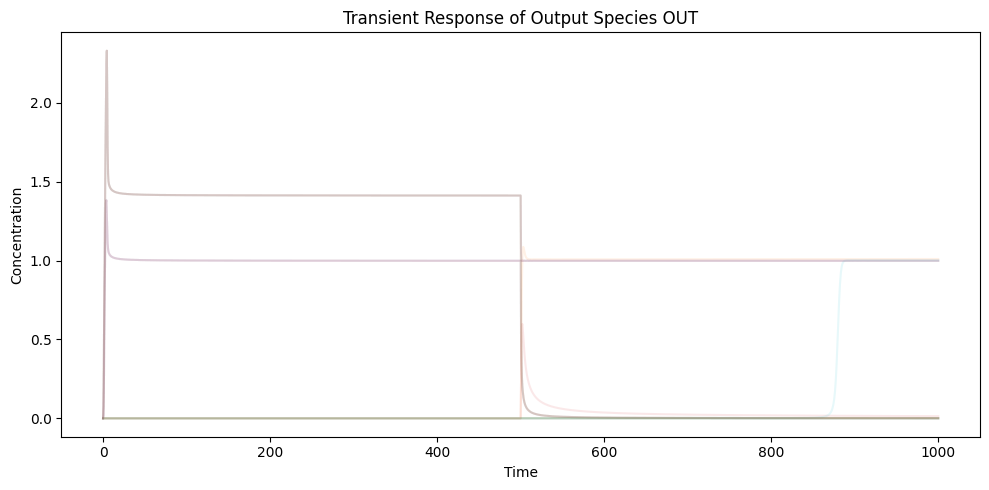

In [29]:
mult_env.hall_of_fame[0].state.plot_transient_response()

In [14]:
hall_of_fame_crns = [env.state for env in mult_env.hall_of_fame]
if save_flag:
    if not os.path.exists('models'):
        os.makedirs('models')
    if not os.path.exists('hof'):
        os.makedirs('hof')
    torch.save(agent.policy.state_dict(), 'models/' + save_filename)
    torch.save(hall_of_fame_crns, 'hof/hall_of_fame_' + save_filename)